# Single CT scan to SPECTRE embeddings

This notebook shows a minimal, practical workflow to:

1. Load one CT scan with **MONAI**.
2. Preprocess and patch the volume exactly like the SPECTRE pipeline.
3. Run the pretrained SPECTRE image model.
4. Do lightweight analysis on resulting embeddings (norms, cosine similarity, PCA).

In [1]:
# Only run this cell when working from a local clone without `pip install -e .`
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidate_src_paths = [cwd / "src", cwd.parent / "src"]
src_path = next((p for p in candidate_src_paths if p.exists()), None)

if src_path is None:
    print("Could not find a local src directory. Checked:")
    for p in candidate_src_paths:
        print(f"  - {p}")
elif str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
    print(f"Added to sys.path: {src_path}")
else:
    print(f"src already on sys.path: {src_path}")

Added to sys.path: C:\Users\20173869\OneDrive - TU Eindhoven\Documents\PhD\Projects\Foundation Models\SPECTRE\src


In [2]:
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from monai.transforms import (
    Compose,
    EnsureChannelFirstd,
    GridPatchd,
    LoadImaged,
    Orientationd,
    ScaleIntensityRanged,
    Spacingd,
)

from spectre import MODEL_CONFIGS, SpectreImageFeatureExtractor
from spectre.transforms import LargestMultipleCenterCropd

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.


Torch version: 2.8.0+cu129
CUDA available: False


## 1) Configure paths and model

Set the CT file path and patch size. The pretrained config will download weights from Hugging Face the first time.

In [4]:
CT_PATH = Path(r"E:\Datasets\CT-RATE\dataset\valid\valid_1\valid_1_a\valid_1_a_1.nii.gz")
PATCH_SIZE = (128, 128, 64)  # (H, W, D)
DO_RESAMPLE = False
RESAMPLE_PIXDIM = (0.5, 0.5, 1.0)
MODEL_NAME = "spectre-large-pretrained"

if not CT_PATH.exists():
    raise FileNotFoundError(
        f"CT file not found: {CT_PATH}\n"
        "Set CT_PATH to an existing .nii/.nii.gz file and rerun this cell."
    )

if MODEL_NAME not in MODEL_CONFIGS:
    raise ValueError(f"Unknown model config: {MODEL_NAME}")

config = MODEL_CONFIGS[MODEL_NAME]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("Model:", MODEL_NAME)
print("Patch size:", PATCH_SIZE)

Using device: cpu
Model: spectre-large-pretrained
Patch size: (128, 128, 64)


## 2) Load and preprocess CT with MONAI

This mirrors the preprocessing in `eval/save_embeddings_ct_rate.py`:
- `LoadImaged`
- `EnsureChannelFirstd`
- `ScaleIntensityRanged` (HU to [0, 1])
- `Orientationd` (RAS)
- optional `Spacingd`
- `LargestMultipleCenterCropd`
- `GridPatchd`

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


Volume shape (C,H,W,D): (1, 1024, 1024, 251)
Cropped shape (C,H,W,D): (1, 1024, 1024, 192)
Grid size (nH,nW,nD): (8, 8, 3)
Patched shape (N,C,pH,pW,pD): (192, 1, 128, 128, 64)
Model input shape (B,N,C,pH,pW,pD): (1, 192, 1, 128, 128, 64)
Voxel spacing (H,W,D) [mm]: (0.3418, 0.3418, 1.5)


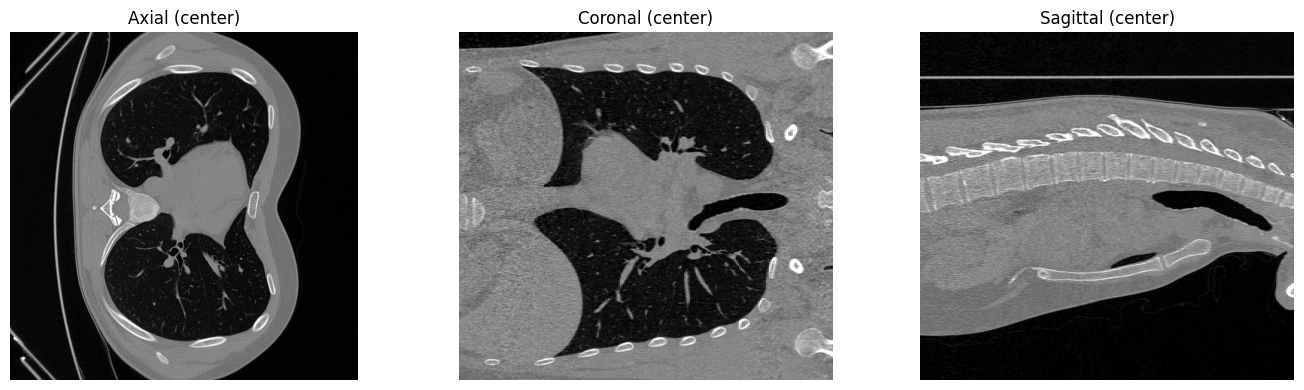

In [5]:
volume_transforms = [
    LoadImaged(keys=("image",)),
    EnsureChannelFirstd(keys=("image",), channel_dim="no_channel"),
    ScaleIntensityRanged(
        keys=("image",),
        a_min=-1000,
        a_max=1000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),
    Orientationd(keys=("image",), axcodes="RAS"),
]
if DO_RESAMPLE:
    volume_transforms.append(
        Spacingd(keys=("image",), pixdim=RESAMPLE_PIXDIM, mode=("bilinear",))
    )

volume_tf = Compose(volume_transforms)
crop_tf = Compose([
    LargestMultipleCenterCropd(keys=("image",), patch_size=PATCH_SIZE),
])
patch_tf = Compose([
    GridPatchd(keys=("image",), patch_size=PATCH_SIZE, overlap=0.0),
])

sample = volume_tf({"image": str(CT_PATH)})
volume = sample["image"]  # (C, H, W, D)

# Try to infer spacing in mm along (H, W, D) from metadata/affine.
def _extract_spacings_mm(img, sample_dict):
    if hasattr(img, "affine") and img.affine is not None:
        aff = np.asarray(img.affine)
        if aff.shape[0] >= 3 and aff.shape[1] >= 3:
            return tuple(float(x) for x in np.linalg.norm(aff[:3, :3], axis=0))

    meta = sample_dict.get("image_meta_dict", {})
    pixdim = meta.get("pixdim", None)
    if pixdim is not None:
        pixdim = np.asarray(pixdim).reshape(-1)
        if pixdim.size >= 4:
            return tuple(float(abs(x)) for x in pixdim[1:4])

    return (1.0, 1.0, 1.0)

spacing_h, spacing_w, spacing_d = _extract_spacings_mm(volume, sample)

cropped = crop_tf({"image": volume})["image"]  # (C, Hc, Wc, Dc)
grid_size = tuple(int(cropped.shape[i + 1] // PATCH_SIZE[i]) for i in range(3))

patched = patch_tf({"image": cropped})["image"]

if isinstance(patched, list):
    patched = torch.stack([torch.as_tensor(p) for p in patched], dim=0)
else:
    patched = torch.as_tensor(patched)

if patched.ndim == 4:
    patched = patched.unsqueeze(0)

if patched.ndim != 5:
    raise RuntimeError(f"Unexpected patched tensor shape: {tuple(patched.shape)}")

model_input = patched.unsqueeze(0).float()  # (B, N, C, pH, pW, pD)

print("Volume shape (C,H,W,D):", tuple(volume.shape))
print("Cropped shape (C,H,W,D):", tuple(cropped.shape))
print("Grid size (nH,nW,nD):", grid_size)
print("Patched shape (N,C,pH,pW,pD):", tuple(patched.shape))
print("Model input shape (B,N,C,pH,pW,pD):", tuple(model_input.shape))
print(
    "Voxel spacing (H,W,D) [mm]:",
    tuple(round(s, 4) for s in (spacing_h, spacing_w, spacing_d)),
)

v = volume.squeeze(0).cpu().numpy()
cz, cy, cx = v.shape[2] // 2, v.shape[1] // 2, v.shape[0] // 2

# For imshow, aspect = row_spacing / column_spacing for true physical scaling.
axial_aspect = spacing_h / spacing_w
coronal_aspect = spacing_h / spacing_d
sagittal_aspect = spacing_w / spacing_d

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(v[:, :, cz], cmap="gray", aspect=axial_aspect)
axes[0].set_title("Axial (center)")
axes[1].imshow(v[:, cy, :], cmap="gray", aspect=coronal_aspect)
axes[1].set_title("Coronal (center)")
axes[2].imshow(v[cx, :, :], cmap="gray", aspect=sagittal_aspect)
axes[2].set_title("Sagittal (center)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3) Run SPECTRE and extract embeddings

We use `SpectreImageFeatureExtractor.from_config` with `spectre-large-pretrained`.

In [7]:
model = SpectreImageFeatureExtractor.from_config(config)
model = model.to(device).eval()

if hasattr(model_input, "as_tensor"):
    model_input = model_input.as_tensor()  # plain torch.Tensor
model_input = model_input.float()

with torch.no_grad():
    embeddings = model(model_input.to(device), grid_size=grid_size)

embeddings_cpu = embeddings.detach().cpu()

print("Embeddings shape:", tuple(embeddings_cpu.shape))
print("Dtype:", embeddings_cpu.dtype)

# Optional: save embeddings for downstream use
save_path = CT_PATH.with_suffix("").with_suffix("").parent / f"{CT_PATH.stem}_spectre_embeddings.pt"
torch.save(
    {
        "ct_path": str(CT_PATH),
        "patch_size": PATCH_SIZE,
        "grid_size": grid_size,
        "embeddings": embeddings_cpu,
    },
    save_path,
)
print("Saved embeddings to:", save_path)

Loading checkpoint from local path: C:\Users\20173869\.cache\huggingface\hub\models--cclaess--SPECTRE\snapshots\b166c0bd4867cdc1d31eda445f2d538572d3dfff\spectre_backbone_vit_large_patch16_128.pt
Loaded pretrained weights with msg: <All keys matched successfully>
Loading checkpoint from local path: C:\Users\20173869\.cache\huggingface\hub\models--cclaess--SPECTRE\snapshots\b166c0bd4867cdc1d31eda445f2d538572d3dfff\spectre_combiner_feature_vit_large.pt
Loaded pretrained weights with msg: <All keys matched successfully>
Embeddings shape: (1, 193, 1080)
Dtype: torch.float32
Saved embeddings to: E:\Datasets\CT-RATE\dataset\valid\valid_1\valid_1_a\valid_1_a_1.nii_spectre_embeddings.pt


## 4) Quick embedding analysis

This section provides a simple first look at the embedding geometry.

Token feature matrix: (193, 1080)
Norm mean=33.2342, std=0.0262, min=33.1939, max=33.3106


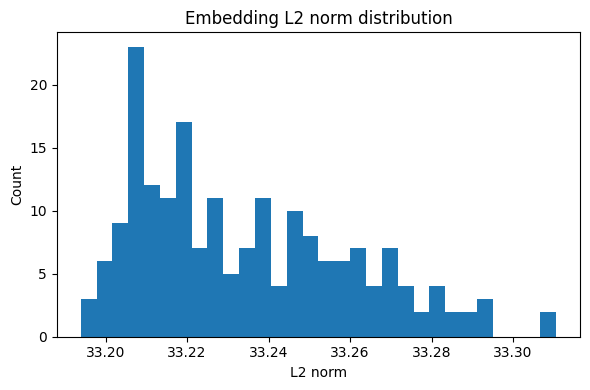

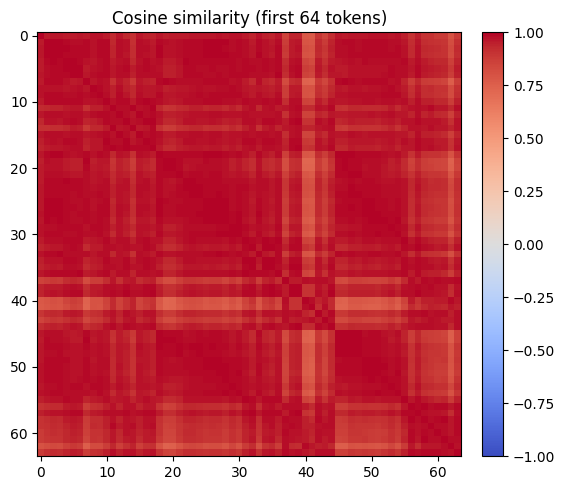

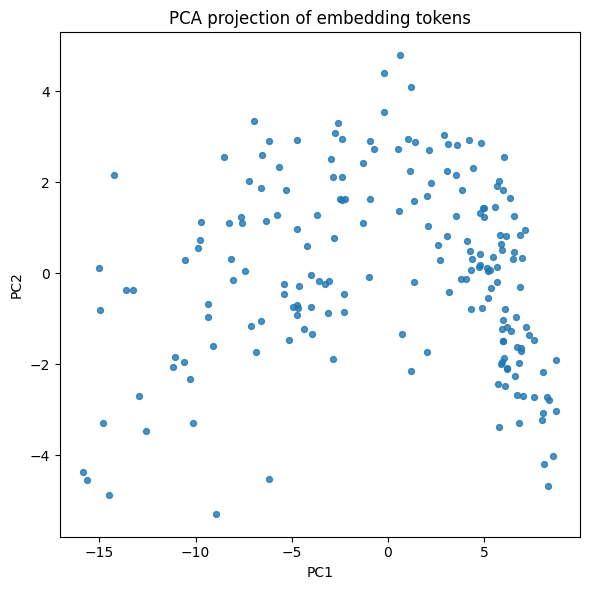

In [8]:
# Flatten tokens for analysis
x = embeddings_cpu
if x.ndim == 4:   # (B, N, T, F)
    token_features = x[0].reshape(-1, x.shape[-1])
elif x.ndim == 3: # (B, T, F)
    token_features = x[0]
else:
    raise RuntimeError(f"Unexpected embedding shape: {tuple(x.shape)}")

print("Token feature matrix:", tuple(token_features.shape))

# 1) Norm distribution
norms = token_features.norm(dim=-1).numpy()
print(f"Norm mean={norms.mean():.4f}, std={norms.std():.4f}, min={norms.min():.4f}, max={norms.max():.4f}")

plt.figure(figsize=(6, 4))
plt.hist(norms, bins=30)
plt.title("Embedding L2 norm distribution")
plt.xlabel("L2 norm")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2) Cosine similarity matrix (first max_tokens tokens for readability)
max_tokens = min(64, token_features.shape[0])
subset = token_features[:max_tokens]
subset = F.normalize(subset, dim=-1)
cos_sim = (subset @ subset.T).numpy()

plt.figure(figsize=(6, 5))
plt.imshow(cos_sim, vmin=-1.0, vmax=1.0, cmap="coolwarm")
plt.title(f"Cosine similarity (first {max_tokens} tokens)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# 3) PCA (torch-based) to 2D
X = token_features - token_features.mean(dim=0, keepdim=True)
q = min(3, X.shape[0], X.shape[1])
U, S, V = torch.pca_lowrank(X, q=q)
coords = X @ V[:, :2]
coords_np = coords.numpy()

plt.figure(figsize=(6, 6))
plt.scatter(coords_np[:, 0], coords_np[:, 1], s=18, alpha=0.8)
plt.title("PCA projection of embedding tokens")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()